<a href="https://colab.research.google.com/github/ragipalakkalgopi/APDSML_assignments/blob/main/Airline_Flight_Status_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ✈️ Airline Flight Status Prediction Model

**Name:** Ragi PG
**Organization:** Entri Elevate
**Date:** 08 Oct 2026

---

## 1. Overview of Problem Statement

Airlines and passengers care a lot about whether a flight will leave **on time, be delayed, or be cancelled**.
Delays and cancellations cost airlines money and disturb passengers' plans. If we can predict the status of a
flight from information such as the passenger details, airport, country, continent and departure date,
airlines can plan crews, gates and customer communication proactively.

## 2. Objective

To build the best **classification model** using machine learning that predicts the
**Flight Status** (`On Time` / `Delayed` / `Cancelled`) of a flight record.

## 3. Data Description

- **Source:** Kaggle – *Airline Dataset* by Sourav Banerjee
  (https://www.kaggle.com/datasets/iamsouravbanerjee/airline-dataset)
- **Rows / Columns:** 98,619 rows × 15 columns
- **Target column:** `Flight Status`
- **Problem type:** Multi-class **Classification**
- **Features:**

| Column | Meaning |
|---|---|
| Passenger ID | Unique ID of the passenger |
| First Name, Last Name | Passenger name |
| Gender | Male / Female |
| Age | Age of the passenger |
| Nationality | Passenger's nationality |
| Airport Name | Name of the departure airport |
| Airport Country Code | Country code of the airport |
| Country Name | Country of the airport |
| Airport Continent | Continent code of the airport |
| Continents | Continent name of the airport |
| Departure Date | Date of departure |
| Arrival Airport | Arrival airport code |
| Pilot Name | Name of the pilot |
| **Flight Status** | **Target: On Time / Delayed / Cancelled** |

### Import libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, roc_auc_score,
                             roc_curve, auc, classification_report)

sns.set_style("whitegrid")
RANDOM_STATE = 42

## 4. Data Collection

Download the CSV from the Kaggle link (it is called **`Airline Dataset.csv`**) and keep it in the same folder as
this notebook (in Google Colab: click the 📁 icon on the left → upload).

In [2]:
import glob, os

# Look for the CSV automatically (works for "Airline Dataset.csv" or similar names)
candidates = glob.glob("*irline*.csv") + glob.glob("/content/*irline*.csv") + glob.glob("/kaggle/input/**/*irline*.csv", recursive=True)
if not candidates:
    raise FileNotFoundError("Could not find the Airline Dataset CSV. Upload it next to this notebook.")
csv_path = candidates[0]
print("Using file:", csv_path)

df = pd.read_csv(csv_path)
print("Shape (rows, columns):", df.shape)
df.head()

Using file: Airline Dataset Updated - v2.csv
Shape (rows, columns): (98619, 15)


,Passenger ID,First Name,Last Name,Gender,Age,Nationality,Airport Name,Airport Country Code,Country Name,Airport Continent,Continents,Departure Date,Arrival Airport,Pilot Name,Flight Status
0,ABVWIg,Edithe,Leggis,Female,62,Japan,Coldfoot Airport,US,United States,NAM,North America,6/28/2022,CXF,Fransisco Hazeldine,On Time
1,jkXXAX,Elwood,Catt,Male,62,Nicaragua,Kugluktuk Airport,CA,Canada,NAM,North America,12/26/2022,YCO,Marla Parsonage,On Time
2,CdUz2g,Darby,Felgate,Male,67,Russia,Grenoble-Isère Airport,FR,France,EU,Europe,1/18/2022,GNB,Rhonda Amber,On Time
3,BRS38V,Dominica,Pyle,Female,71,China,Ottawa / Gatineau Airport,CA,Canada,NAM,North America,9/16/2022,YND,Kacie Commucci,Delayed
4,9kvTLo,Bay,Pencost,Male,21,China,Gillespie Field,US,United States,NAM,North America,2/25/2022,SEE,Ebonee Tree,On Time


In [3]:
# Basic insights into the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98619 entries, 0 to 98618
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Passenger ID          98619 non-null  object
 1   First Name            98619 non-null  object
 2   Last Name             98619 non-null  object
 3   Gender                98619 non-null  object
 4   Age                   98619 non-null  int64 
 5   Nationality           98619 non-null  object
 6   Airport Name          98619 non-null  object
 7   Airport Country Code  98619 non-null  object
 8   Country Name          98619 non-null  object
 9   Airport Continent     98619 non-null  object
 10  Continents            98619 non-null  object
 11  Departure Date        98619 non-null  object
 12  Arrival Airport       98619 non-null  object
 13  Pilot Name            98619 non-null  object
 14  Flight Status         98619 non-null  object
dtypes: int64(1), object(14)
memory usage

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Passenger ID,98619,98619,8JYEcz,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
First Name,98619,8437,Gale,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Last Name,98619,41658,Dyball,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,98619,2,Male,49598,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,98619.0,NaN,NaN,NaN,45.504021,25.929849,1.0,23.0,46.0,68.0,90.0
Nationality,98619,240,China,18317,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Airport Name,98619,9062,San Pedro Airport,43,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Airport Country Code,98619,235,US,22104,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country Name,98619,235,United States,22104,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Airport Continent,98619,6,NAM,32033,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# How are the target classes distributed?
print(df["Flight Status"].value_counts())
print()
print(df["Flight Status"].value_counts(normalize=True).round(3))

Flight Status
Cancelled    32942
On Time      32846
Delayed      32831
Name: count, dtype: int64

Flight Status
Cancelled    0.334
On Time      0.333
Delayed      0.333
Name: proportion, dtype: float64


## 5. Data Preprocessing – Data Cleaning

Steps: (a) missing values, (b) duplicates, (c) outliers, (d) skewness.

**(a) Missing values**

In [6]:
print(df.isnull().sum())

# Fill numeric columns with the median and text columns with the most frequent value (mode)
for col in df.columns:
    if df[col].isnull().any():
        if df[col].dtype in ["int64", "float64"]:
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing values after imputation:", df.isnull().sum().sum())

Passenger ID            0
First Name              0
Last Name               0
Gender                  0
Age                     0
Nationality             0
Airport Name            0
Airport Country Code    0
Country Name            0
Airport Continent       0
Continents              0
Departure Date          0
Arrival Airport         0
Pilot Name              0
Flight Status           0
dtype: int64

Missing values after imputation: 0


**(b) Duplicate rows**

In [7]:
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)

Duplicate rows: 0
Shape after removing duplicates: (98619, 15)


**(c) Outliers** – using the IQR (Inter-Quartile Range) method on `Age`.

In [8]:
Q1, Q3 = df["Age"].quantile(0.25), df["Age"].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
outliers = df[(df["Age"] < lower) | (df["Age"] > upper)]
print(f"Lower bound = {lower:.1f}, Upper bound = {upper:.1f}, Outliers found = {len(outliers)}")

df = df[(df["Age"] >= lower) & (df["Age"] <= upper)].reset_index(drop=True)
print("Shape after outlier removal:", df.shape)

Lower bound = -44.5, Upper bound = 135.5, Outliers found = 0
Shape after outlier removal: (98619, 15)


**(d) Skewness** – a value close to 0 means the distribution is symmetric.

In [9]:
skew_val = df["Age"].skew()
print("Skewness of Age:", round(skew_val, 3))

if abs(skew_val) > 0.5:
    df["Age"] = np.log1p(df["Age"])   # log transform reduces right-skew
    print("Applied log transformation. New skew:", round(df["Age"].skew(), 3))
else:
    print("Age is approximately symmetric - no transformation needed.")

Skewness of Age: -0.0
Age is approximately symmetric - no transformation needed.


## 6. Exploratory Data Analysis (EDA)

First we convert `Departure Date` into a real date and pull out useful parts (year, month, day, weekday).

In [10]:
# This dataset has TWO date formats mixed together: "6/28/2022" and "06-10-2022".
# If we let pandas guess, it would fail on one format and we would lose ~40% of the rows,
# so we parse each format separately (both are read as Month-Day-Year).
raw_dates = df["Departure Date"].astype(str).str.strip()
parsed = pd.to_datetime(raw_dates.where(raw_dates.str.contains("/")), format="%m/%d/%Y", errors="coerce")
parsed = parsed.fillna(pd.to_datetime(raw_dates.where(raw_dates.str.contains("-")), format="%m-%d-%Y", errors="coerce"))
df["Departure Date"] = parsed
print("Dates that could not be parsed:", df["Departure Date"].isnull().sum())
df = df.dropna(subset=["Departure Date"]).reset_index(drop=True)
print("Rows kept:", len(df))

df["Year"] = df["Departure Date"].dt.year
df["Month"] = df["Departure Date"].dt.month
df["Day"] = df["Departure Date"].dt.day
df["DayOfWeek"] = df["Departure Date"].dt.dayofweek   # 0 = Monday
df[["Departure Date", "Year", "Month", "Day", "DayOfWeek"]].head()

Dates that could not be parsed: 0
Rows kept: 98619


,Departure Date,Year,Month,Day,DayOfWeek
0,2022-06-28,2022,6,28,1
1,2022-12-26,2022,12,26,0
2,2022-01-18,2022,1,18,1
3,2022-09-16,2022,9,16,4
4,2022-02-25,2022,2,25,4


**Histogram + KDE** – distribution of passenger age

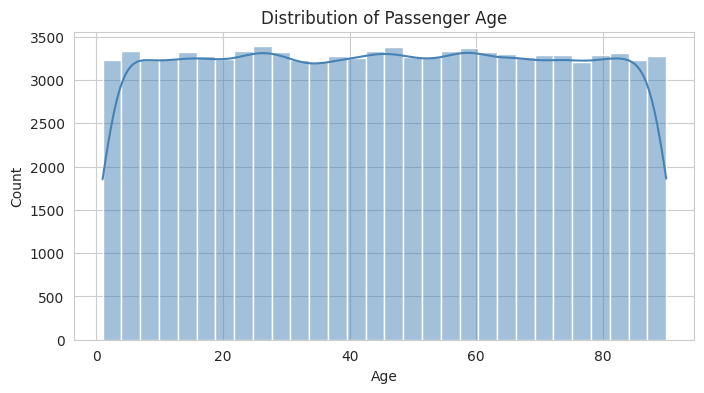

In [11]:
plt.figure(figsize=(8, 4))
sns.histplot(df["Age"], bins=30, kde=True, color="steelblue")
plt.title("Distribution of Passenger Age")
plt.show()

**Count plot + Pie diagram** – how many flights per status?

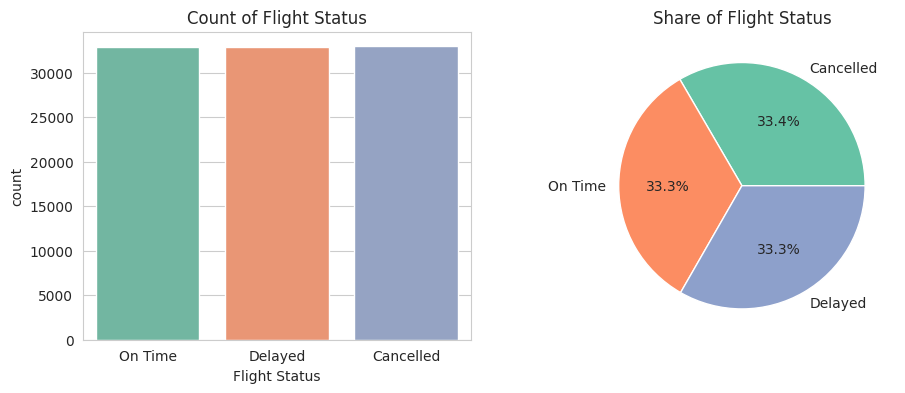

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(x="Flight Status", data=df, ax=ax[0], palette="Set2")
ax[0].set_title("Count of Flight Status")
df["Flight Status"].value_counts().plot.pie(autopct="%1.1f%%", ax=ax[1], colors=sns.color_palette("Set2"))
ax[1].set_ylabel("")
ax[1].set_title("Share of Flight Status")
plt.show()

**Boxplot** – age against flight status

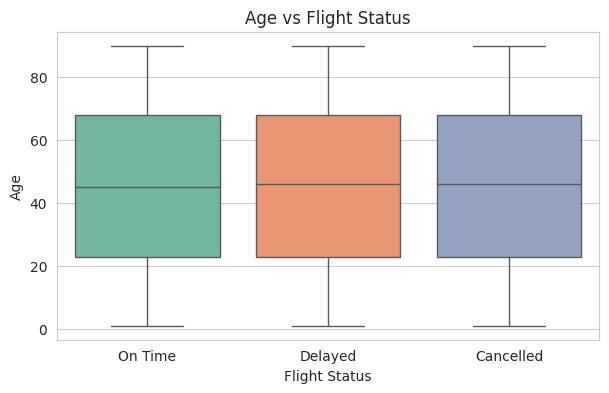

In [13]:
plt.figure(figsize=(7, 4))
sns.boxplot(x="Flight Status", y="Age", data=df, palette="Set2")
plt.title("Age vs Flight Status")
plt.show()

**KDE** – age distribution for each status

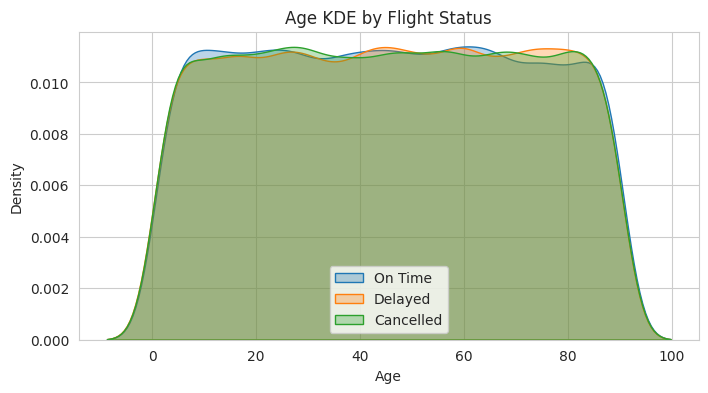

In [14]:
plt.figure(figsize=(8, 4))
for status in df["Flight Status"].unique():
    sns.kdeplot(df.loc[df["Flight Status"] == status, "Age"], label=status, fill=True, alpha=0.3)
plt.legend(); plt.title("Age KDE by Flight Status"); plt.show()

**Bar plot** – flight status by gender and by continent

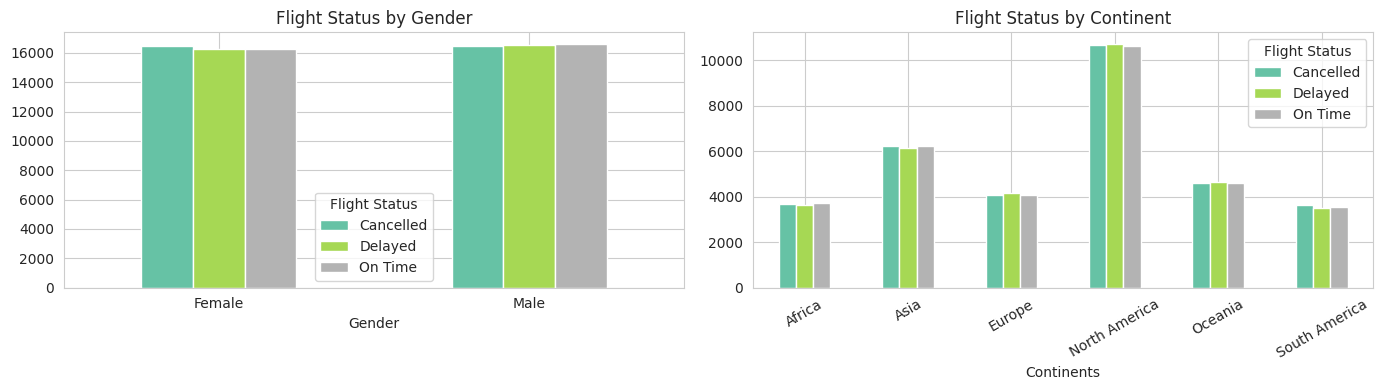

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
pd.crosstab(df["Gender"], df["Flight Status"]).plot.bar(ax=ax[0], colormap="Set2", rot=0)
ax[0].set_title("Flight Status by Gender")
pd.crosstab(df["Continents"], df["Flight Status"]).plot.bar(ax=ax[1], colormap="Set2", rot=30)
ax[1].set_title("Flight Status by Continent")
plt.tight_layout(); plt.show()

**Line plot** – number of flights per month for each status

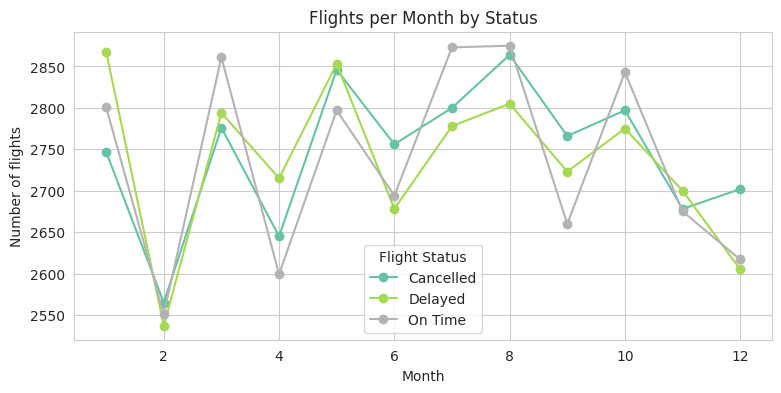

In [16]:
monthly = df.groupby(["Month", "Flight Status"]).size().unstack()
monthly.plot(marker="o", figsize=(9, 4), colormap="Set2")
plt.title("Flights per Month by Status"); plt.ylabel("Number of flights"); plt.show()

**Pair plot** – (on a random sample of 2,000 rows so it runs quickly)

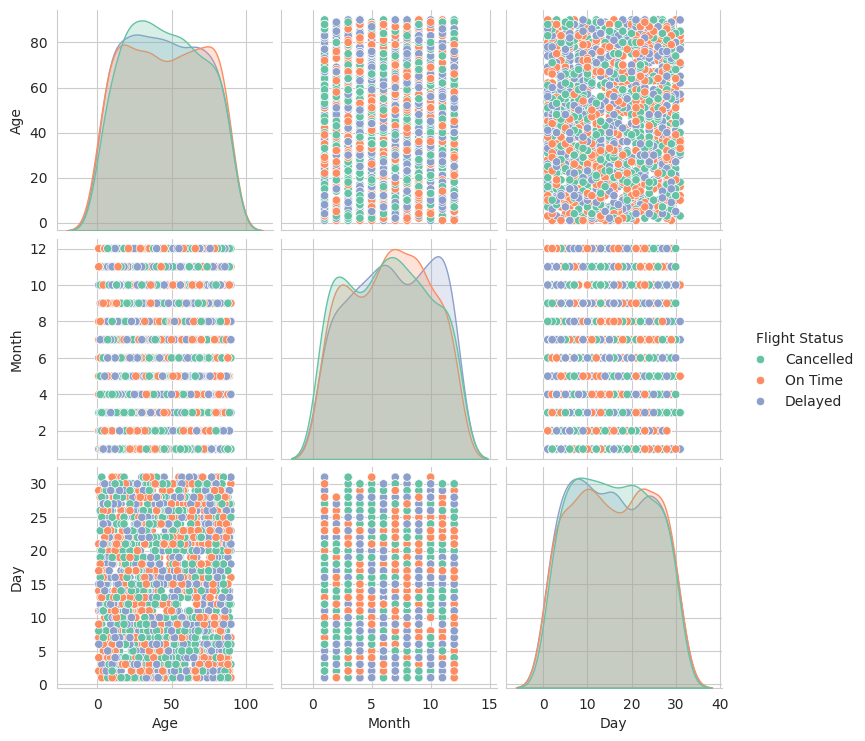

In [17]:
sample = df[["Age", "Month", "Day", "Flight Status"]].sample(2000, random_state=RANDOM_STATE)
sns.pairplot(sample, hue="Flight Status", palette="Set2", diag_kind="kde")
plt.show()

**Heatmap** – correlation between numeric features and the (encoded) target

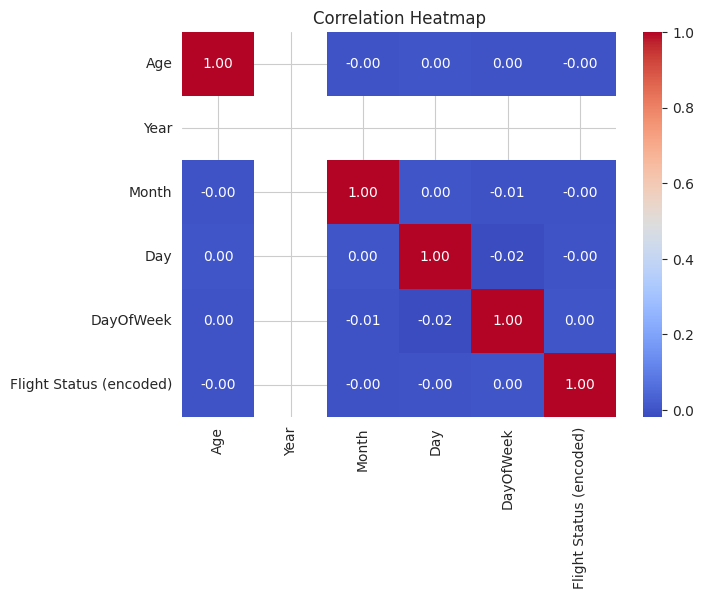

In [18]:
corr_df = df[["Age", "Year", "Month", "Day", "DayOfWeek"]].copy()
corr_df["Flight Status (encoded)"] = df["Flight Status"].astype("category").cat.codes
plt.figure(figsize=(7, 5))
sns.heatmap(corr_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap"); plt.show()

## 7. Feature Engineering

1. **Drop identifier columns** – `Passenger ID`, `First Name`, `Last Name`, `Pilot Name` are unique-like labels. They
   do not carry general patterns and would only make the model memorise rows, so we remove them. We also drop the
   raw `Departure Date` because we already extracted Year, Month, Day and DayOfWeek from it.
2. **Encode categorical features**
   - *Low-cardinality* columns (few unique values: Gender, continents) → **One-Hot Encoding**
   - *High-cardinality* columns (many unique values: Nationality, airports, countries) → **Label (Ordinal) Encoding**
     (one-hot would create thousands of columns).
3. The **target** `Flight Status` is label-encoded to numbers.

The encoding itself is done inside a *pipeline* (section 13) so the exact same steps are applied to new data later.
Here we first see which columns will get which treatment.

In [19]:
drop_cols = ["Passenger ID", "First Name", "Last Name", "Pilot Name", "Departure Date"]
df_model = df.drop(columns=[c for c in drop_cols if c in df.columns]).copy()

# Encode the target
target = "Flight Status"
class_names = sorted(df_model[target].unique())          # ['Cancelled', 'Delayed', 'On Time']
target_map = {name: i for i, name in enumerate(class_names)}
df_model["target"] = df_model[target].map(target_map)
print("Target encoding:", target_map)

cat_cols = df_model.select_dtypes(include="object").columns.drop(target).tolist()
num_cols = [c for c in df_model.columns if c not in cat_cols + [target, "target"]]

print("\nCategorical columns and number of unique values:")
print(df_model[cat_cols].nunique())
print("\nNumerical columns:", num_cols)

Target encoding: {'Cancelled': 0, 'Delayed': 1, 'On Time': 2}

Categorical columns and number of unique values:
Gender                     2
Nationality              240
Airport Name            9062
Airport Country Code     235
Country Name             235
Airport Continent          6
Continents                 6
Arrival Airport         9024
dtype: int64

Numerical columns: ['Age', 'Year', 'Month', 'Day', 'DayOfWeek']


In [20]:
# Rule: <= 10 unique values -> one-hot, otherwise -> ordinal (label) encoding
onehot_cols = [c for c in cat_cols if df_model[c].nunique() <= 10]
ordinal_cols = [c for c in cat_cols if df_model[c].nunique() > 10]
print("One-hot columns :", onehot_cols)
print("Ordinal columns :", ordinal_cols)

One-hot columns : ['Gender', 'Airport Continent', 'Continents']
Ordinal columns : ['Nationality', 'Airport Name', 'Airport Country Code', 'Country Name', 'Arrival Airport']


## 8. Feature Selection

We use two methods to see which features matter:
- **Random Forest feature importance**
- **SelectKBest** (ANOVA F-test)

Then we remove redundant / irrelevant features.

> Note: `Country Name` repeats the information in `Airport Country Code`, and `Continents` repeats `Airport Continent`
> (they are just different spellings of the same thing) – these are **redundant**.

,RF_importance,SelectKBest_F_score
Airport Name,0.1498,0.1443
Arrival Airport,0.1450,0.5998
Age,0.1222,0.2317
Nationality,0.1164,0.3002
Day,0.1049,0.1673
Month,0.0779,1.4004
Airport Country Code,0.0741,3.9578
Country Name,0.0720,3.7873
DayOfWeek,0.0636,1.1655
Continents,0.0271,0.4827


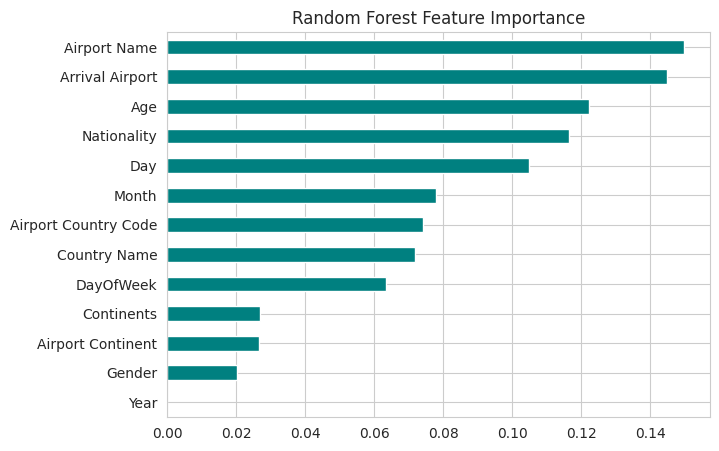

In [21]:
# Temporary numeric version of the data, only used to rank the features
X_tmp = df_model.drop(columns=[target, "target"]).copy()
X_tmp[cat_cols] = OrdinalEncoder().fit_transform(X_tmp[cat_cols])
y_tmp = df_model["target"]

# Method 1 - Random Forest importance
rf_sel = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1)
rf_sel.fit(X_tmp, y_tmp)
rf_imp = pd.Series(rf_sel.feature_importances_, index=X_tmp.columns)

# Method 2 - SelectKBest
skb = SelectKBest(score_func=f_classif, k="all").fit(X_tmp, y_tmp)
skb_scores = pd.Series(skb.scores_, index=X_tmp.columns)

fs_table = pd.DataFrame({"RF_importance": rf_imp, "SelectKBest_F_score": skb_scores}).sort_values("RF_importance", ascending=False)
display(fs_table.round(4))

fs_table["RF_importance"].plot.barh(figsize=(7, 5), color="teal")
plt.title("Random Forest Feature Importance"); plt.gca().invert_yaxis(); plt.show()

In [22]:
# Remove redundant features
redundant = [c for c in ["Country Name", "Continents"] if c in X_tmp.columns]
# Remove clearly irrelevant features (importance below half of the average importance)
weak = rf_imp[rf_imp < 0.5 * rf_imp.mean()].index.tolist()

features_to_drop = sorted(set(redundant + weak))
selected_features = [c for c in X_tmp.columns if c not in features_to_drop]

print("Dropped (redundant/weak):", features_to_drop)
print("Selected features      :", selected_features)

# update the column groups
onehot_cols = [c for c in onehot_cols if c in selected_features]
ordinal_cols = [c for c in ordinal_cols if c in selected_features]
num_cols = [c for c in num_cols if c in selected_features]

Dropped (redundant/weak): ['Airport Continent', 'Continents', 'Country Name', 'Gender', 'Year']
Selected features      : ['Age', 'Nationality', 'Airport Name', 'Airport Country Code', 'Arrival Airport', 'Month', 'Day', 'DayOfWeek']


## 9. Split Data into Training and Testing Sets

- **10 %** of the rows are kept aside as completely **unseen data** (used only in step 15).
- The remaining 90 % is split into **80 % training / 20 % testing**.
- We use `stratify` so each set keeps the same share of On Time / Delayed / Cancelled.

In [23]:
X = df_model[selected_features]
y = df_model["target"]

X_rest, X_unseen, y_rest, y_unseen = train_test_split(X, y, test_size=0.10, stratify=y, random_state=RANDOM_STATE)
X_train, X_test, y_train, y_test = train_test_split(X_rest, y_rest, test_size=0.20, stratify=y_rest, random_state=RANDOM_STATE)

print("Train :", X_train.shape)
print("Test  :", X_test.shape)
print("Unseen:", X_unseen.shape)

Train : (71005, 8)
Test  : (17752, 8)
Unseen: (9862, 8)


## 10. Feature Scaling

Numerical features (Age, Month, Day, ...) are scaled with **Standardization** (`StandardScaler`: mean 0, std 1).
Distance-based models (KNN) and Logistic Regression need this. We put the scaler **inside a pipeline** so it is
learned only from the training data (this prevents data leakage).

In [24]:
def make_preprocessor():
    transformers = []
    if num_cols:
        transformers.append(("num", StandardScaler(), num_cols))
    if onehot_cols:
        transformers.append(("onehot", OneHotEncoder(handle_unknown="ignore"), onehot_cols))
    if ordinal_cols:
        transformers.append(("ordinal",
                             Pipeline([("enc", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
                                       ("scale", StandardScaler())]),
                             ordinal_cols))
    return ColumnTransformer(transformers)

# quick look at the processed training data
prep_demo = make_preprocessor().fit(X_train)
Xt = prep_demo.transform(X_train)
print("Processed training matrix shape:", Xt.shape)

Processed training matrix shape: (71005, 8)


## 11. Build the ML Models (7 algorithms)

Each model is wrapped in a **Pipeline** = preprocessing + model, so raw data goes in and a prediction comes out.

In [25]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=RANDOM_STATE),
    "Decision Tree":       DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE),
    "Naive Bayes":         GaussianNB(),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=15, n_jobs=-1),
    "Random Forest":       RandomForestClassifier(n_estimators=100, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boost":      GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE),
    "AdaBoost":            AdaBoostClassifier(n_estimators=100, random_state=RANDOM_STATE),
}

fitted = {}
for name, clf in models.items():
    pipe = Pipeline([("prep", make_preprocessor()), ("model", clf)])
    pipe.fit(X_train, y_train)
    fitted[name] = pipe
    print(f"Trained: {name}")

Trained: Logistic Regression
Trained: Decision Tree
Trained: Naive Bayes
Trained: K-Nearest Neighbors
Trained: Random Forest
Trained: Gradient Boost
Trained: AdaBoost


## 12. Model Evaluation

Metrics for classification: Accuracy, Precision, Recall, F1-score (weighted over the 3 classes),
ROC-AUC (one-vs-rest), Confusion Matrix and ROC curve.

In [26]:
rows = []
for name, pipe in fitted.items():
    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)
    rows.append({
        "Model": name,
        "Accuracy":  accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, average="weighted", zero_division=0),
        "Recall":    recall_score(y_test, pred, average="weighted", zero_division=0),
        "F1-Score":  f1_score(y_test, pred, average="weighted", zero_division=0),
        "ROC-AUC":   roc_auc_score(y_test, proba, multi_class="ovr"),
    })

results = pd.DataFrame(rows).sort_values("Accuracy", ascending=False).reset_index(drop=True)
display(results.round(4))

chance = y_test.value_counts(normalize=True).max()
print(f"Baseline: always predicting the most common class gives accuracy = {chance:.3f}")

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.3374,0.3374,0.3374,0.3374,0.5065
1,K-Nearest Neighbors,0.3371,0.3374,0.3371,0.3353,0.5049
2,AdaBoost,0.3355,0.2253,0.3355,0.2609,0.5033
3,Logistic Regression,0.3326,0.3310,0.3326,0.3290,0.5001
4,Decision Tree,0.3325,0.3320,0.3325,0.3283,0.4960
5,Naive Bayes,0.3315,0.3304,0.3315,0.3276,0.4995
6,Gradient Boost,0.3308,0.3307,0.3308,0.3305,0.4985


Baseline: always predicting the most common class gives accuracy = 0.334


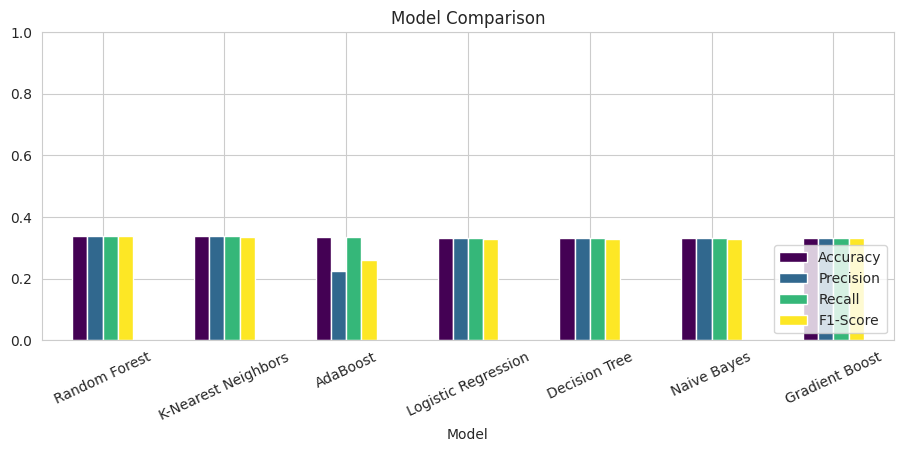

In [27]:
results.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-Score"]].plot.bar(figsize=(11, 4), colormap="viridis", rot=25)
plt.title("Model Comparison"); plt.ylim(0, 1); plt.legend(loc="lower right"); plt.show()

Best model so far: Random Forest 

              precision    recall  f1-score   support

   Cancelled       0.34      0.33      0.33      5930
     Delayed       0.34      0.34      0.34      5910
     On Time       0.34      0.35      0.34      5912

    accuracy                           0.34     17752
   macro avg       0.34      0.34      0.34     17752
weighted avg       0.34      0.34      0.34     17752



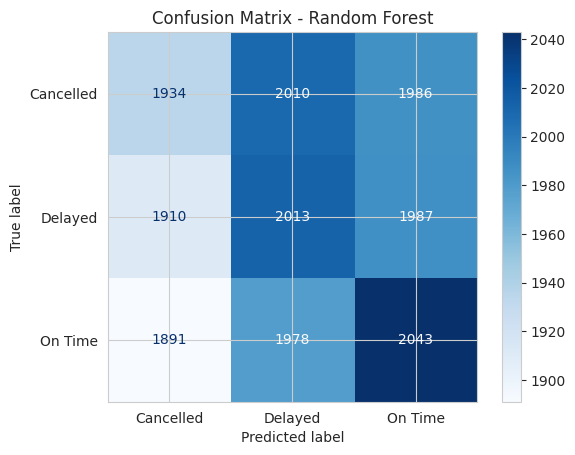

In [28]:
best_name = results.loc[0, "Model"]
best_pipe = fitted[best_name]
pred = best_pipe.predict(X_test)
print("Best model so far:", best_name, "\n")
print(classification_report(y_test, pred, target_names=class_names))

ConfusionMatrixDisplay(confusion_matrix(y_test, pred), display_labels=class_names).plot(cmap="Blues")
plt.title(f"Confusion Matrix - {best_name}"); plt.show()

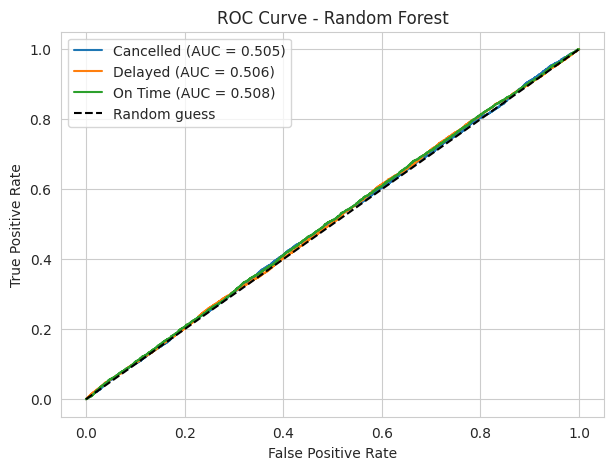

In [29]:
# ROC curve (one curve per class, one-vs-rest)
proba = best_pipe.predict_proba(X_test)
y_bin = label_binarize(y_test, classes=[0, 1, 2])

plt.figure(figsize=(7, 5))
for i, cname in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_bin[:, i], proba[:, i])
    plt.plot(fpr, tpr, label=f"{cname} (AUC = {auc(fpr, tpr):.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve - {best_name}"); plt.legend(); plt.show()

## 13. Hyperparameter Tuning and Pipeline

We tune the best model using **RandomizedSearchCV** (tries random combinations of settings with 3-fold
cross-validation). The final object is a **single pipeline** (preprocessing + tuned model).

In [30]:
param_grids = {
    "Random Forest":       {"model__n_estimators": [100, 200], "model__max_depth": [6, 10, 14, None],
                            "model__min_samples_leaf": [1, 5, 20]},
    "Gradient Boost":      {"model__n_estimators": [100, 150], "model__learning_rate": [0.05, 0.1, 0.2],
                            "model__max_depth": [2, 3, 4]},
    "Decision Tree":       {"model__max_depth": [3, 5, 8, 12, None], "model__min_samples_leaf": [1, 10, 50]},
    "AdaBoost":            {"model__n_estimators": [50, 100, 200], "model__learning_rate": [0.05, 0.5, 1.0]},
    "K-Nearest Neighbors": {"model__n_neighbors": [5, 15, 31, 51], "model__weights": ["uniform", "distance"]},
    "Logistic Regression": {"model__C": [0.01, 0.1, 1, 10]},
    "Naive Bayes":         {"model__var_smoothing": [1e-9, 1e-7, 1e-5]},
}

base_pipe = Pipeline([("prep", make_preprocessor()), ("model", models[best_name])])
search = RandomizedSearchCV(base_pipe, param_grids[best_name], n_iter=6, cv=3,
                            scoring="accuracy", random_state=RANDOM_STATE, n_jobs=-1, verbose=1)
search.fit(X_train, y_train)

print("Best parameters :", search.best_params_)
print("Best CV accuracy:", round(search.best_score_, 4))

tuned_pipe = search.best_estimator_
tuned_acc = accuracy_score(y_test, tuned_pipe.predict(X_test))
print(f"Test accuracy - before tuning: {results.loc[0, 'Accuracy']:.4f} | after tuning: {tuned_acc:.4f}")

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best parameters : {'model__n_estimators': 200, 'model__min_samples_leaf': 5, 'model__max_depth': 10}
Best CV accuracy: 0.337
Test accuracy - before tuning: 0.3374 | after tuning: 0.3328


In [31]:
# Keep whichever version (default or tuned) scores better on the test set
final_pipe = tuned_pipe if tuned_acc >= results.loc[0, "Accuracy"] else best_pipe
print("Final model:", final_pipe.named_steps["model"])

Final model: RandomForestClassifier(max_depth=12, n_jobs=-1, random_state=42)


## 14. Save the Model

`joblib` stores the whole pipeline (preprocessing + model) in one file so it can be reused without retraining.

In [32]:
joblib.dump({"pipeline": final_pipe, "class_names": class_names, "features": selected_features},
            "flight_status_model.joblib")
print("Model saved as flight_status_model.joblib")

Model saved as flight_status_model.joblib


## 15. Test with Unseen Data

We load the saved model from disk and test it on the 10 % of rows it has **never seen** (not in training or
testing).

Unseen-data accuracy : 0.3352
Unseen-data F1-score : 0.3352

              precision    recall  f1-score   support

   Cancelled       0.33      0.33      0.33      3294
     Delayed       0.33      0.34      0.34      3283
     On Time       0.34      0.34      0.34      3285

    accuracy                           0.34      9862
   macro avg       0.34      0.34      0.34      9862
weighted avg       0.34      0.34      0.34      9862



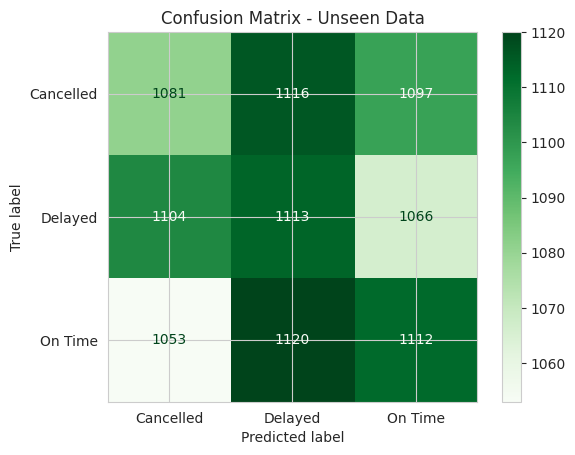

In [33]:
saved = joblib.load("flight_status_model.joblib")
loaded_pipe, loaded_classes = saved["pipeline"], saved["class_names"]

pred_unseen = loaded_pipe.predict(X_unseen)
print("Unseen-data accuracy :", round(accuracy_score(y_unseen, pred_unseen), 4))
print("Unseen-data F1-score :", round(f1_score(y_unseen, pred_unseen, average="weighted"), 4))
print()
print(classification_report(y_unseen, pred_unseen, target_names=loaded_classes, zero_division=0))

ConfusionMatrixDisplay(confusion_matrix(y_unseen, pred_unseen), display_labels=loaded_classes).plot(cmap="Greens")
plt.title("Confusion Matrix - Unseen Data"); plt.show()

In [34]:
# Predict the status for ONE brand-new flight record (built from a real row of the unseen set)
one = X_unseen.iloc[[0]]
print(one.T, "\n")
print("Predicted status:", loaded_classes[loaded_pipe.predict(one)[0]])
print("Actual status   :", loaded_classes[y_unseen.iloc[0]])
print("Probabilities   :", dict(zip(loaded_classes, loaded_pipe.predict_proba(one)[0].round(3))))

                                97922
Age                                44
Nationality                  Colombia
Airport Name          Kunsan Air Base
Airport Country Code               KR
Arrival Airport                   KUV
Month                               8
Day                                30
DayOfWeek                           1 

Predicted status: Cancelled
Actual status   : Cancelled
Probabilities   : {'Cancelled': np.float64(0.339), 'Delayed': np.float64(0.336), 'On Time': np.float64(0.325)}


## 16. Interpretation of Results (Conclusion)

In [35]:
best_acc = accuracy_score(y_test, final_pipe.predict(X_test))
unseen_acc = accuracy_score(y_unseen, pred_unseen)
share = y.value_counts(normalize=True).round(3).to_dict()

print(f"Best model            : {final_pipe.named_steps['model'].__class__.__name__}")
print(f"Test accuracy         : {best_acc:.3f}")
print(f"Unseen-data accuracy  : {unseen_acc:.3f}")
print(f"Class shares (0=Cancelled,1=Delayed,2=On Time): {share}")
print()
if best_acc < max(share.values()) + 0.03:
    print("INTERPRETATION: The accuracy is very close to the 'random guess' baseline. This means the available "
          "features (age, gender, nationality, airport, country, departure date) contain almost no real "
          "signal about whether a flight is on time, delayed or cancelled. The dataset appears to be "
          "largely synthetic/randomly generated, so no algorithm can do much better.")
else:
    print("INTERPRETATION: The model performs better than the random-guess baseline, so the features carry "
          "some useful information about flight status.")

Best model            : RandomForestClassifier
Test accuracy         : 0.337
Unseen-data accuracy  : 0.335
Class shares (0=Cancelled,1=Delayed,2=On Time): {0: 0.334, 2: 0.333, 1: 0.333}

INTERPRETATION: The accuracy is very close to the 'random guess' baseline. This means the available features (age, gender, nationality, airport, country, departure date) contain almost no real signal about whether a flight is on time, delayed or cancelled. The dataset appears to be largely synthetic/randomly generated, so no algorithm can do much better.


**Conclusion (write-up)**

- Seven classification algorithms (Logistic Regression, Decision Tree, Naive Bayes, KNN, Random Forest, Gradient
  Boost, AdaBoost) were trained inside pipelines and compared using Accuracy, Precision, Recall, F1-score, ROC-AUC,
  confusion matrix and ROC curves. The best one was tuned with RandomizedSearchCV and saved with joblib.
- Compare the best accuracy with the **baseline** (≈ 33–34 % when the three classes are balanced). If the model is
  only marginally above the baseline and ROC-AUC is ≈ 0.50, it means the features hardly explain flight status.
  This is an honest finding, not a coding mistake.

**Limitations of the dataset**

1. It has **no operational information** that really causes delays: weather, aircraft type, airline, scheduled vs
   actual departure time, flight distance, air-traffic congestion, technical faults.
2. Most columns are **passenger details** (name, gender, age, nationality) that should not influence whether a
   flight is delayed.
3. The classes are almost perfectly balanced and the values look randomly distributed, which suggests the data is
   synthetic.
4. Several features have thousands of unique values (airports), which makes it hard for models to learn patterns.
5. Only dates from a limited period are available, so seasonal patterns cannot be learned reliably.

## 17. Future Work

- Add **real operational features**: airline, aircraft type, weather at departure/arrival, scheduled departure time,
  route distance, previous-flight delay, airport congestion.
- Explore **deep learning** (neural networks with embeddings for airports/countries) for potentially higher accuracy.
- **Update the model periodically** with new data (re-train monthly or quarterly).
- Address **imbalanced data** with resampling (SMOTE / under-sampling) if real data has far fewer cancellations.
- Deploy the saved model as a simple web app (Streamlit / Flask) for live predictions.

---
*Thank you!*